In [64]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv('/content/loan_approval.csv')

df = df.drop(['name', 'city'], axis=1)

df['loan_approved'] = df['loan_approved'].astype(int)

In [66]:
X = df.drop(['loan_approved', 'points'], axis=1)
y = df['loan_approved']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [69]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [70]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['income', 'credit_score', 'loan_amount', 'years_employed'], dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [71]:
y_pred = model.predict(X_test)

Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       217
           1       0.97      0.97      0.97       183

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



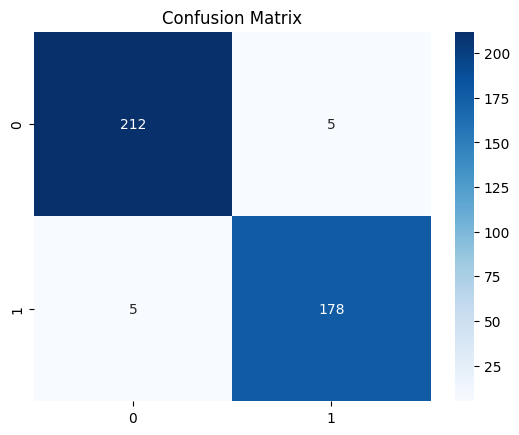

In [72]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

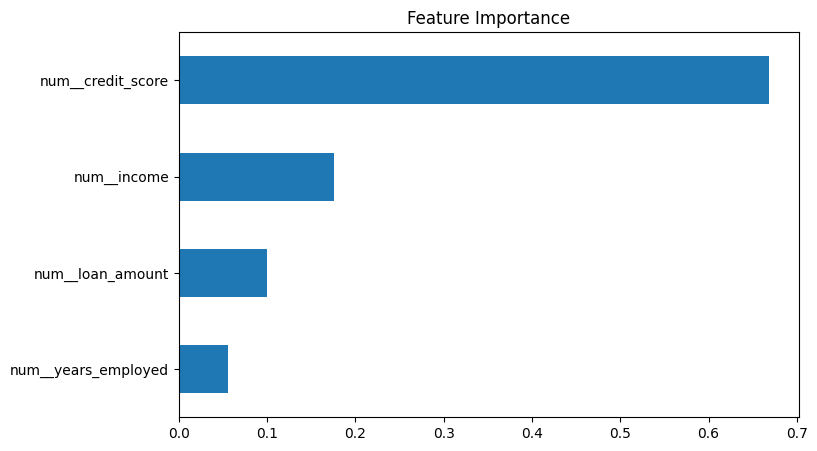

num__credit_score      0.668848
num__income            0.175884
num__loan_amount       0.099466
num__years_employed    0.055802
dtype: float64


In [73]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['classifier'].feature_importances_

importance_df = pd.Series(importances, index=feature_names)
importance_df.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

print(importance_df.sort_values(ascending=False))

In [76]:
new_applicant = pd.DataFrame([{
    'income': 75000,
    'credit_score': 720,
    'loan_amount': 20000,
    'years_employed': 10
}])

prediction = model.predict(new_applicant)

print("\nLoan Approved" if prediction[0] == 1 else "Loan Rejected")


Loan Approved


In [75]:
print("\nPoints vs Loan Approval:")
print(pd.crosstab(df['points'], df['loan_approved']))


Points vs Loan Approval:
loan_approved    0    1
points                 
10.0             4    0
15.0             3    0
20.0            18    0
25.0            95    0
30.0            59    0
35.0           127    0
40.0           164    0
45.0           170    0
50.0           271    0
55.0           210    0
60.0             0  193
65.0             0  130
70.0             0  111
75.0             0  119
80.0             0   97
85.0             0   94
90.0             0   77
95.0             0   38
100.0            0   20


In [79]:
import joblib

joblib.dump(model, "loan_model.pkl")

['loan_model.pkl']

In [80]:
from google.colab import files

files.download("loan_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>